In [1]:
import numpy as np
from matplotlib import pyplot as plt

from loki.libloki.configs import PulsarSearchConfig
from loki.libloki.plans import FFAPlanFourier
from loki.libloki.prune import EPMultiPassFourier
from pyloki.config import ParamLimits
from pyloki.detection import thresholding
from pyloki.periodogram import PruningStatsPlotter, ScatteredPeriodogram
from pyloki.simulation.pulse import PulseSignalConfig

tobs = 1073.741824


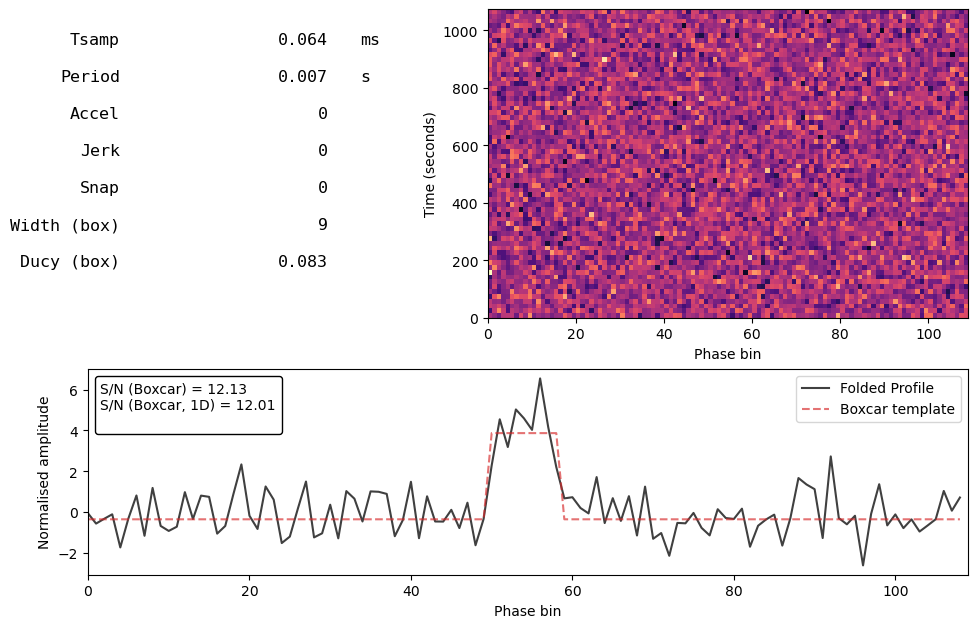

In [2]:
pulsar_period = 0.007
dt = 64e-6
nsamps = 2**24
mod_kwargs = {"p_orb": 1200, "psi": np.pi / 4.1, "m_c": 8}
cfg = PulseSignalConfig(
    period=pulsar_period,
    dt=dt,
    nsamps=nsamps,
    snr=12,
    ducy=0.1,
    mod_kwargs=mod_kwargs,
    mod_type="circular",
)
print(f"tobs = {cfg.tobs}")
tim_data = cfg.generate(shape="gaussian")
tim_data.plot_fold(cfg.freq, cfg.fold_bins, mod_kwargs=mod_kwargs, mod_type="circular")
plt.show()

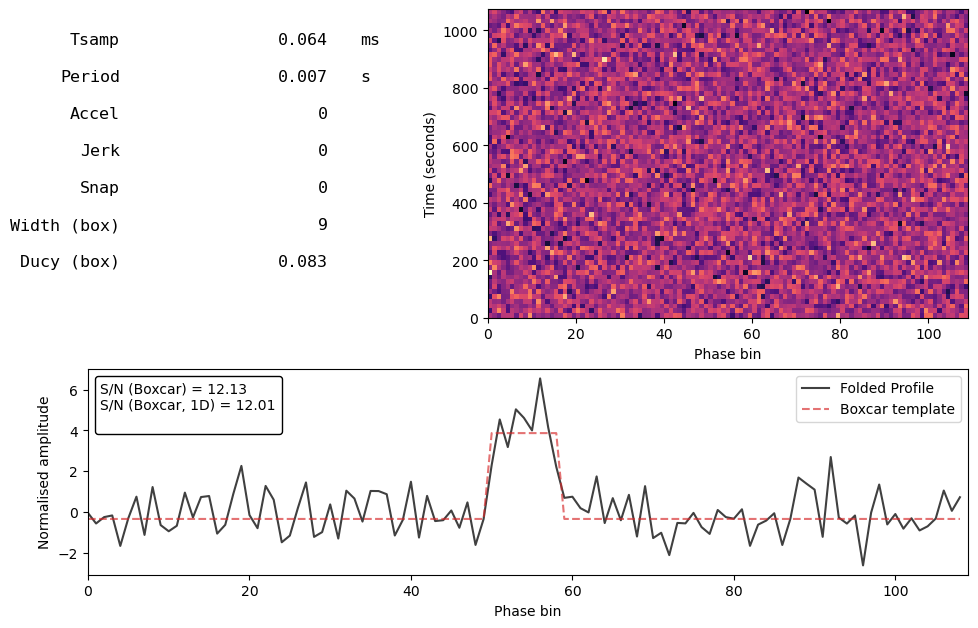

In [3]:
tim_data.plot_fold(
    cfg.freq,
    cfg.fold_bins,
    mod_kwargs=cfg.mod_func.to_derivatives_series(n=15),
    mod_type="derivative_series",
)
plt.show()

In [4]:
eta = 1
nbins = 64
p_orb_min = 1100
m_p_min=1.4
m_c_max=12
p = ParamLimits.from_circular(1 / 0.007, p_orb_min, m_c_max, m_p=m_p_min, poly_order=5)
print(f"Param limits: {p.limits}")
bseg_brute = cfg.nsamps // 8192
bseg_ffa = cfg.nsamps // 128
search_cfg = PulsarSearchConfig(
    nsamps=cfg.nsamps,
    tsamp=cfg.dt,
    nbins=nbins,
    eta=eta,
    param_limits=p.limits,
    bseg_brute=bseg_brute,
    bseg_ffa=bseg_ffa,
    prune_poly_order=5,
    nthreads=4,
    ducy_max=0.2,
    wtsp=1.1,
    use_fourier=True,
    m_p_min=m_p_min,
    m_c_max=m_c_max,
    p_orb_min=p_orb_min,
)
plan = FFAPlanFourier(search_cfg)
branching_pattern = plan.get_branching_pattern()
branching_pattern

Param limits: [[-2.06585480e-03  2.06585480e-03]
 [-3.61670104e-01  3.61670104e-01]
 [-6.33177432e+01  6.33177432e+01]
 [-1.10850650e+04  1.10850650e+04]
 [ 1.41932376e+02  1.43781910e+02]]


array([8.        , 3.        , 2.        , 3.        , 3.        ,
       1.        , 6.        , 3.        , 1.        , 1.        ,
       3.        , 1.        , 1.        , 3.        , 6.        ,
       3.        , 1.        , 1.        , 1.        , 3.        ,
       1.        , 1.        , 3.        , 1.        , 3.        ,
       1.5       , 1.        , 1.        , 1.        , 1.        ,
       2.        , 1.        , 1.        , 3.        , 3.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 3.        , 1.        ,
       3.        , 1.        , 1.        , 3.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 3.        ,
       1.        , 1.        , 2.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       3.        , 1.        , 1.        , 1.        , 1.     

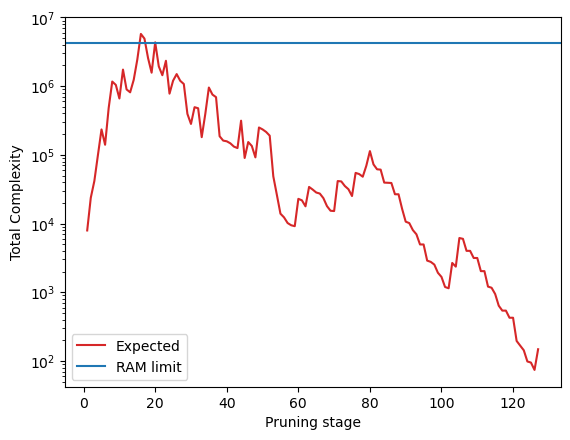

In [5]:
thresholds = np.array([1.2, 1.7, 2.2, 2.4, 2.5, 2.8, 3. , 2.9, 2.8, 3.1, 3. , 3.4, 3.2,
       3.6, 4. , 3.9, 3.8, 4.1, 4.2, 4. , 4.4, 4.4, 4.6, 4.9, 5. , 4.9,
       4.9, 4.8, 5.2, 5.2, 5.1, 4.9, 5.4, 5.4, 5.4, 5.4, 5.3, 5.8, 5.7,
       5.5, 5.5, 5.5, 5.4, 5.5, 6. , 6.1, 6. , 6.1, 6. , 5.9, 5.9, 5.9,
       6.4, 6.5, 6.6, 6.5, 6.5, 6.4, 6.3, 6.4, 6.3, 6.4, 6.3, 6.3, 6.3,
       6.2, 6.3, 6.4, 6.4, 6.2, 6.3, 6.1, 6.3, 6.3, 6.4, 6.5, 6.4, 6.4,
       6.5, 6.2, 6.6, 6.6, 6.4, 6.7, 6.5, 6.4, 6.7, 6.3, 6.8, 6.9, 6.8,
       6.9, 6.9, 7. , 6.6, 7.1, 7. , 7. , 7.1, 7.1, 7.2, 7.1, 7.2, 7.2,
       7.2, 7.1, 7.3, 6.9, 7.3, 6.9, 7.4, 7. , 7.5, 7.4, 7.5, 7.6, 7.6,
       7.2, 7.6, 7.3, 7.8, 7.8, 7.8, 7.9, 7.8, 7.9, 7.5])
thresh_state = thresholding.evaluate_scheme(
    thresholds,
    branching_pattern,
    ref_ducy=0.1,
    nbins=64,
    ntrials=1024,
    snr_final=12,
    ducy_max=0.2,
    wtsp=1.1,
)
x = np.arange(1, len(branching_pattern) + 1)
nparam_vol = plan.ncoords[-1]
plt.semilogy(
    x,
    np.array(thresh_state.get_info("complexity")) * nparam_vol,
    label="Expected",
    c="tab:red",
)
plt.axhline(2**22, label="RAM limit", c="tab:blue")
plt.xlabel("Pruning stage")
plt.ylabel("Total Complexity")
plt.legend()
plt.show()

In [6]:
ep_manager = EPMultiPassFourier(search_cfg, thresholds, n_runs=16, max_sugg=2**22, batch_size=1024, poly_basis="taylor", show_progress=False)
ep_manager.execute(tim_data.ts_e, tim_data.ts_v, outdir="pruning_results/circular_test/", file_prefix="test_circular")

[2026-04-09 20:27:23.645] [info] EPMultiPass: Initializing with FFA
[2026-04-09 20:27:23.654] [info] P-FFA [8192, 1, 1, 1, 1, 7, 2, 33] -> [128, 1, 1, 1, 2, 496, 2, 33]
[2026-04-09 20:27:23.654] [info] FFA Memory Usage: 0.12 GB + 0.00 GB (coords)
[2026-04-09 20:27:24.021] [info] Starting Pruning for 16 runs, with 4 threads
[2026-04-09 20:27:24.032] [info] Pruning run 025: Memory Usage: 2.54 GB (tree) + 0.02 GB (workspace)
[2026-04-09 20:27:24.032] [info] Pruning run 008: Memory Usage: 2.54 GB (tree) + 0.02 GB (workspace)
[2026-04-09 20:27:24.032] [info] Pruning run 025: initialized
[2026-04-09 20:27:24.032] [info] Pruning run 000: Memory Usage: 2.54 GB (tree) + 0.02 GB (workspace)
[2026-04-09 20:27:24.032] [info] Pruning run 016: Memory Usage: 2.54 GB (tree) + 0.02 GB (workspace)
[2026-04-09 20:27:24.032] [info] Pruning run 000: initialized
[2026-04-09 20:27:24.032] [info] Pruning run 008: initialized
[2026-04-09 20:27:24.032] [info] Pruning run 016: initialized
[2026-04-09 20:27:47.39

In [7]:
result_file = (
    "pruning_results/circular_test/test_circular_pruning_nstages_128_results.h5"
)
pgram = ScatteredPeriodogram.load(result_file)
param_true = cfg.mod_func.to_derivatives_gauge(cfg.freq)
crac_true = param_true["crackle"]
snap_true = param_true["snap"]
jerk_true = param_true["jerk"]
acc_true = param_true["acc"]
freq_true = param_true["freq"]
print(
    f"True params, c: {crac_true:.3f}, s: {snap_true:.3f}, j: {jerk_true:.3f}, "
    f"a: {acc_true:.3f}, f: {freq_true:.10f}",
)
print(pgram.get_summary_cands(10, run_id=None))

True params, c: 0.001, s: 0.159, j: -31.566, a: -5802.064, f: 142.3105761558
Top candidates:
dparams: dcrackle: 1.905838106e-06, dsnap: 0.0001112186367, djerk: 0.006490369825, daccel: 0.8542262831, dfreq: 2.910383046e-05
Run: 101_13, S/N: 9.70, crackle: 0.0008694, snap: 0.15959, jerk: -31.6388, accel: -5807.51, freq: 142.310074
Run: 101_13, S/N: 9.60, crackle: 0.0008694, snap: 0.15959, jerk: -31.6388, accel: -5807.51, freq: 142.310103
Run: 101_13, S/N: 9.55, crackle: 0.0008672, snap: 0.15940, jerk: -31.5974, accel: -5807.98, freq: 142.310338
Run: 101_13, S/N: 9.52, crackle: 0.0008672, snap: 0.15940, jerk: -31.5974, accel: -5807.98, freq: 142.310367
Run: 101_13, S/N: 9.46, crackle: 0.0008694, snap: 0.15959, jerk: -31.6388, accel: -5807.50, freq: 142.310161
Run: 101_13, S/N: 9.44, crackle: 0.0008679, snap: 0.15946, jerk: -31.6064, accel: -5807.51, freq: 142.310375
Run: 101_13, S/N: 9.43, crackle: 0.0008694, snap: 0.15959, jerk: -31.6388, accel: -5807.51, freq: 142.310132
Run: 101_13, S/N

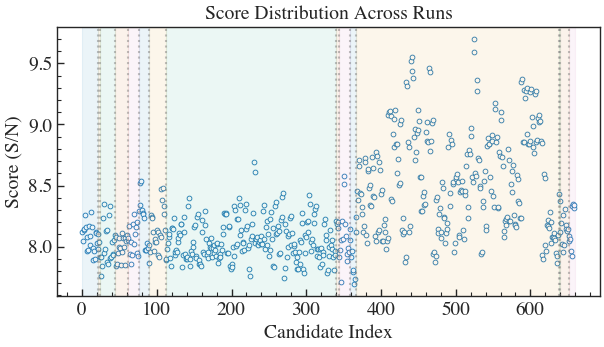

In [8]:
pgram.plot_scores(kind="scatter", run_id=None); plt.show()

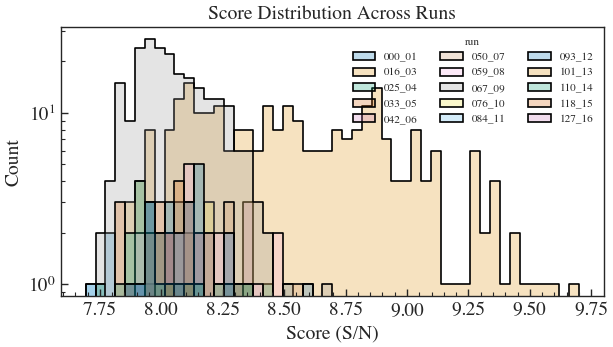

In [9]:
pgram.plot_scores(kind="hist", run_id=None); plt.show()

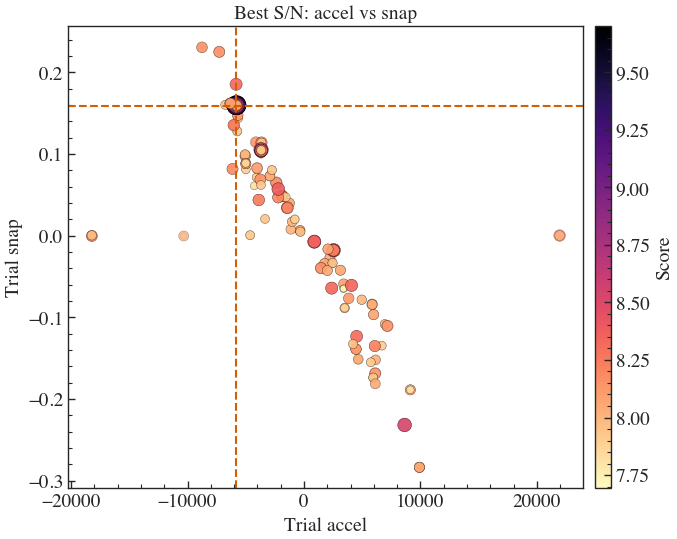

In [10]:
pgram.plot_correlation(
    "accel",
    "snap",
    true_values={"snap": snap_true, "accel": acc_true},
    run_id=None,
)
plt.show()

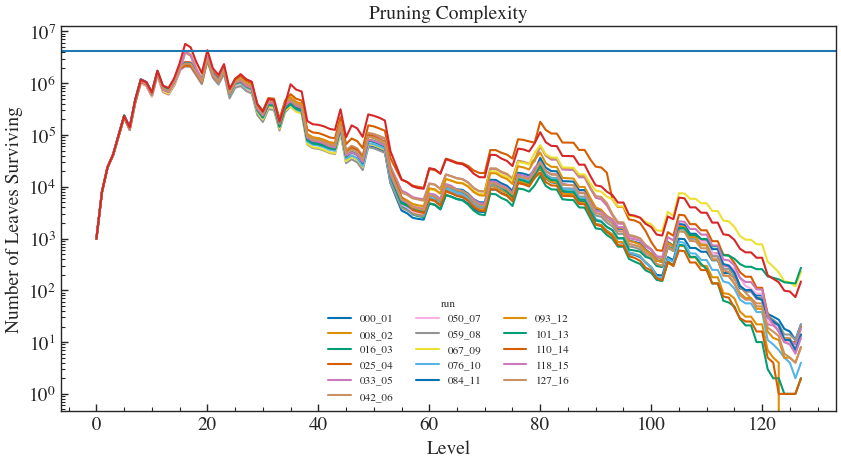

In [11]:
pstats = PruningStatsPlotter.load(result_file)
fig = pstats.plot_level_stats(run_id=None)
x = np.arange(0, len(branching_pattern) + 1)
ax_list = fig.axes
ax_list[0].plot(
    x,
    np.concatenate(([1], thresh_state.get_info("complexity"))) * nparam_vol,
    label="Expected",
    c="tab:red",
)
ax_list[0].axhline(2**22, label="RAM limit", c="tab:blue")
plt.show()